In [155]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [156]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_953

In [157]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['60. Radio', 'MVI_5416.mp4']
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


In [158]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (1080, 1920, 3)


In [159]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

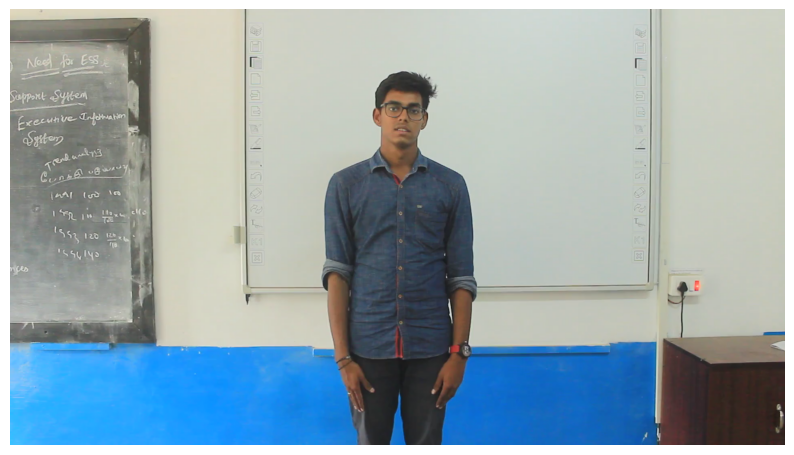

In [160]:
display_cv2_img(img)
cap.release()

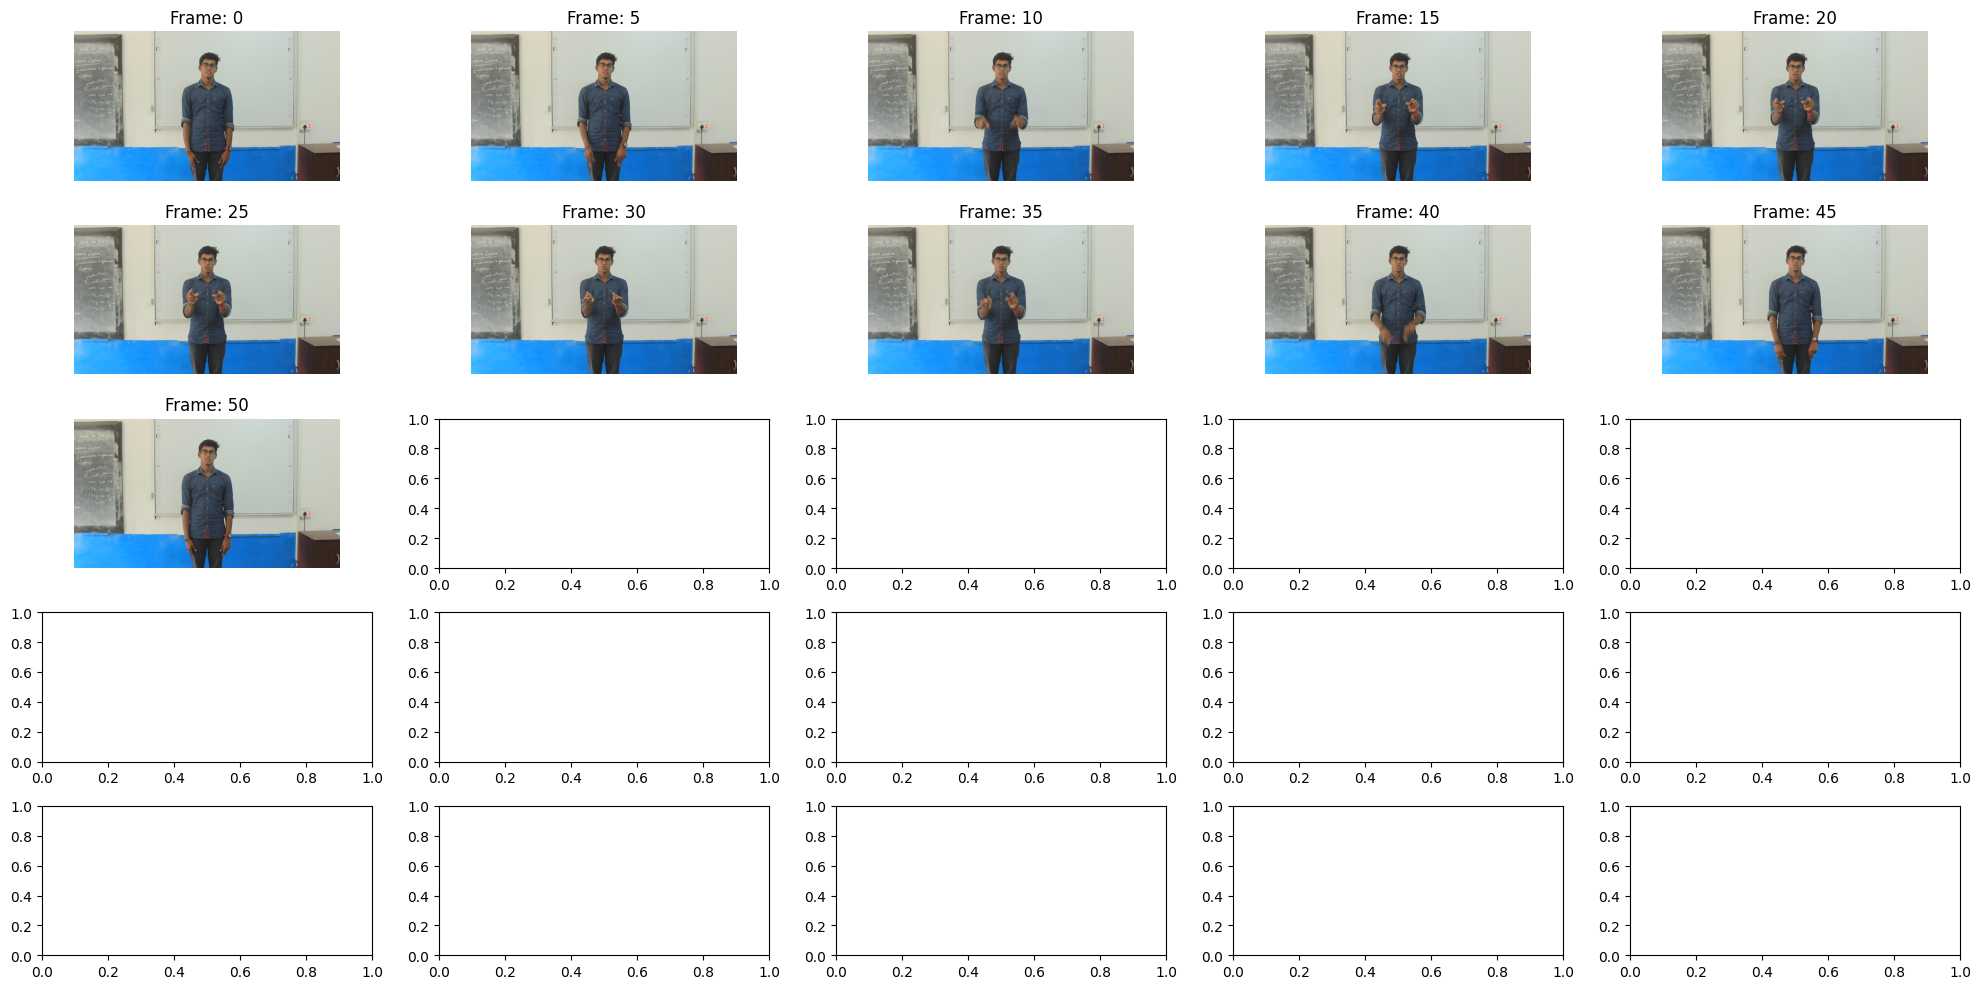

In [161]:
fig, axs = plt.subplots(5, 5, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    if ret == False:
        break
    if frame % 5 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

In [163]:
def centered_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 600
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,700:1300] # Cropping
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Flip


In [164]:
def flip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,::-1] # Flipping
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Downsampling

In [165]:
def downsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 960
    height = 540
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrDown(img) # Downsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Upsampling


In [166]:
def upsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 3840
    height = 2160
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrUp(img) # Upsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


## Genrating all the augmented content


In [184]:
for label in tqdm(glob('Dataset\*\*')): 
    label_name = " ".join(((label.split("\\")[-1]).split(" "))[1:]) # First seprated the label from dir then sep the label from its number and then join the label
    
    # Currently applying augmentation for include 50 dataset only
    if label_name in os.listdir("MP_data"):
        os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
        videos = os.listdir(label)[1:]
        
        for video in tqdm(videos,desc=label.split("\\")[-1]):
            input_video = os.path.join(label, video)
            n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
            centered_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
            flip_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
            downsample_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
            upsample_video(input_video, save_path, cap, n_frames)
    
        

  0%|          | 0/262 [00:00<?, ?it/s]

1. loud:   0%|          | 0/21 [00:00<?, ?it/s]

2. quiet:   0%|          | 0/21 [00:00<?, ?it/s]

3. happy:   0%|          | 0/21 [00:00<?, ?it/s]

78. long:   0%|          | 0/21 [00:00<?, ?it/s]

...

46. you (plural):   0%|          | 0/21 [00:00<?, ?it/s]

61. Summer:   0%|          | 0/14 [00:00<?, ?it/s]

64. Fall:   0%|          | 0/15 [00:00<?, ?it/s]

14. Election:   0%|          | 0/14 [00:00<?, ?it/s]

2. Death:   0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
for label in tqdm(glob('Dataset\*\*')): 
    os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
    videos = os.listdir(label)[1:]
   
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):
        input_video = os.path.join(label, video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
        centered_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
        flip_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
        downsample_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
        upsample_video(input_video, save_path, cap, n_frames)
    

  0%|          | 0/262 [00:00<?, ?it/s]

Dataset\Adjectives\1. loud
Dataset\Adjectives\2. quiet
Dataset\Adjectives\3. happy
Dataset\Animals\1. Dog
Dataset\Animals\4. Bird
Dataset\Animals\5. Cow
Dataset\Society\2. Death
